XGBoost Accuracy: 0.7988826815642458
LightGBM Accuracy: 0.8156424581005587


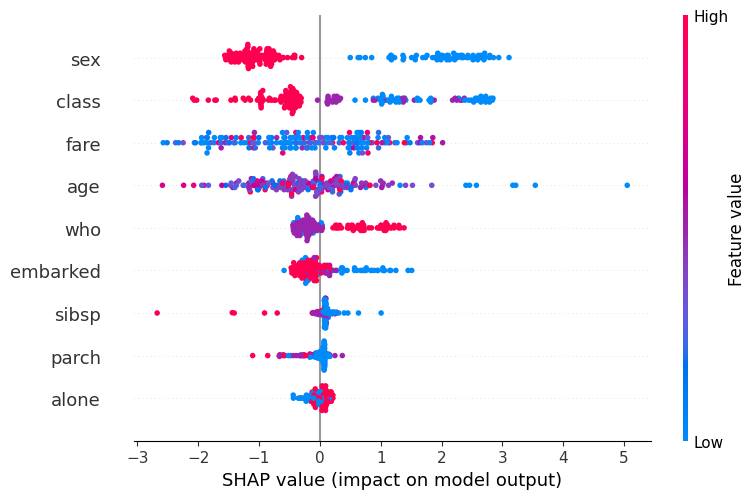

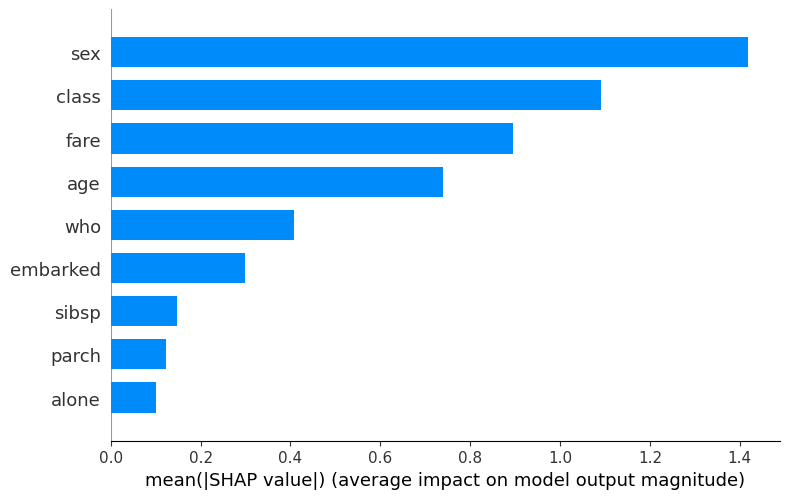

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Load dataset
df = pd.read_csv("Titanic.csv")


# Handle missing values
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


# Convert categorical data
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])
df["class"] = le.fit_transform(df["class"])
df["who"] = le.fit_transform(df["who"])
df["alone"] = df["alone"].astype(int)


# X and y
X = df.drop("survived", axis=1)
y = df["survived"]


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# XGBoost
xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred))


# LightGBM
lgb = LGBMClassifier(random_state=42, verbosity=-1)

lgb.fit(X_train, y_train)

pred2 = lgb.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, pred2))


# SHAP explanation
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)


# SHAP feature importance
shap.summary_plot(shap_values, X_test)


# SHAP bar graph
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)